# Importar librerías

In [ ]:
!pip install tensorflow

In [ ]:
# Librerías estándar
import random
from collections import Counter




# Visualización
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt


# Deep Learning
import tensorflow as tf
# from tensorflow.keras import layers, models
# from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau




import pandas as pd
import numpy as np

from sklearn.datasets import load_wine

# Cargar Dataset

## Justificación del dataset elegido

Se eligió el dataset **Wine** de scikit-learn por las siguientes razones:

- **Tamaño manejable:** Con solo 178 instancias y 13 features, permite iterar rápidamente sobre múltiples experimentos y familias de modelos sin un costo computacional elevado.
- **Calidad de los datos:** No presenta valores faltantes ni registros duplicados, por lo que no se requieren técnicas de imputación ni limpieza adicional.
- **Escalas razonables:** Aunque las features tienen rangos distintos (por ejemplo, `proline` vs `ash`), las diferencias no son extremas y el escalado estándar es suficiente para normalizar los datos antes de entrenar la red neuronal.
- **Problema multi-clase bien definido:** Cuenta con exactamente 3 clases balanceadas, lo cual es ideal para comparar modelos con métricas macro como F1, precision y recall sin que el desbalance de clases sea un factor de confusión.

In [ ]:
dataset = load_wine(as_frame=True)

df = dataset.frame

# Exploración

In [ ]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [ ]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


# EDA

## Número de datos y features

In [ ]:
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

Número de filas: 178
Número de columnas: 14


## Valores nulos (Missing values)

In [ ]:
df.isnull().sum()

,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


## Datos duplicados

In [ ]:
print("Duplicados:", df.duplicated().sum())

Duplicados: 0


## Histogramas por feature

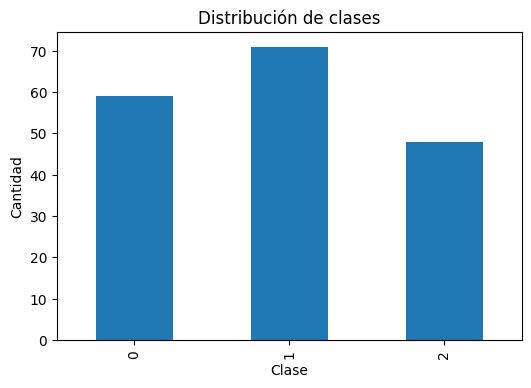

In [ ]:
import matplotlib.pyplot as plt

df["target"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.show()

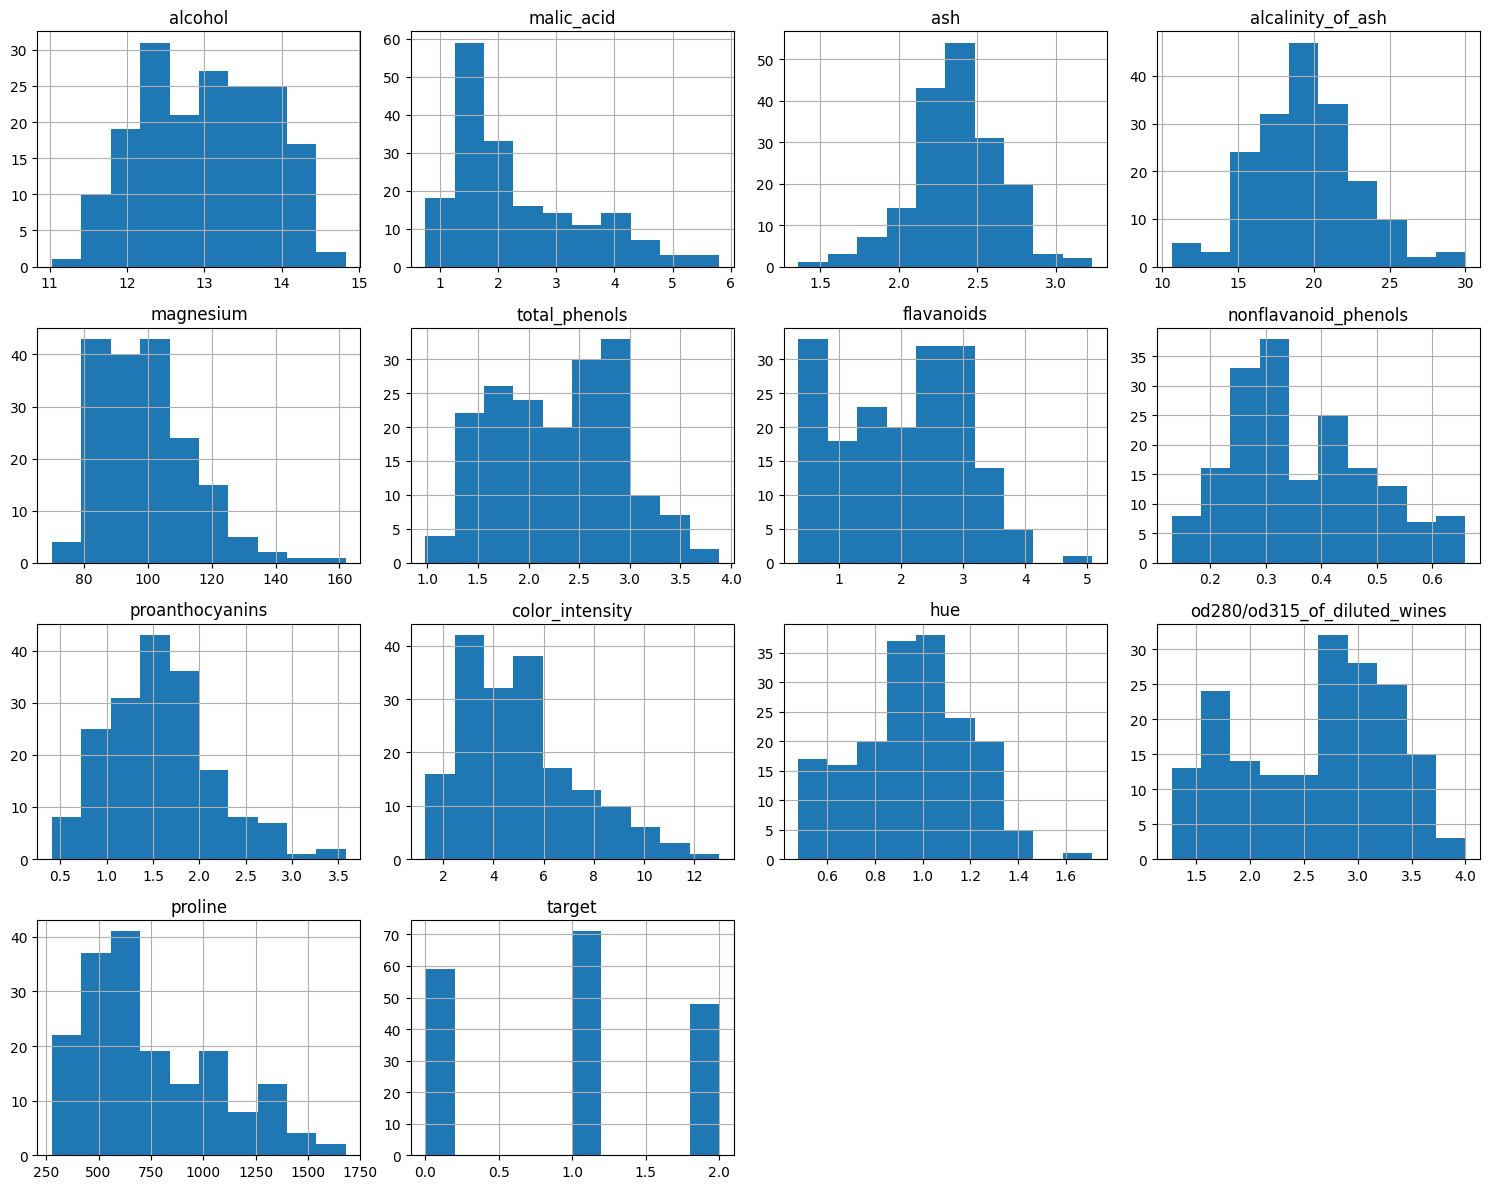

In [ ]:
df.hist(figsize=(15,12))
plt.tight_layout()
plt.show()

## Analisis de correlación

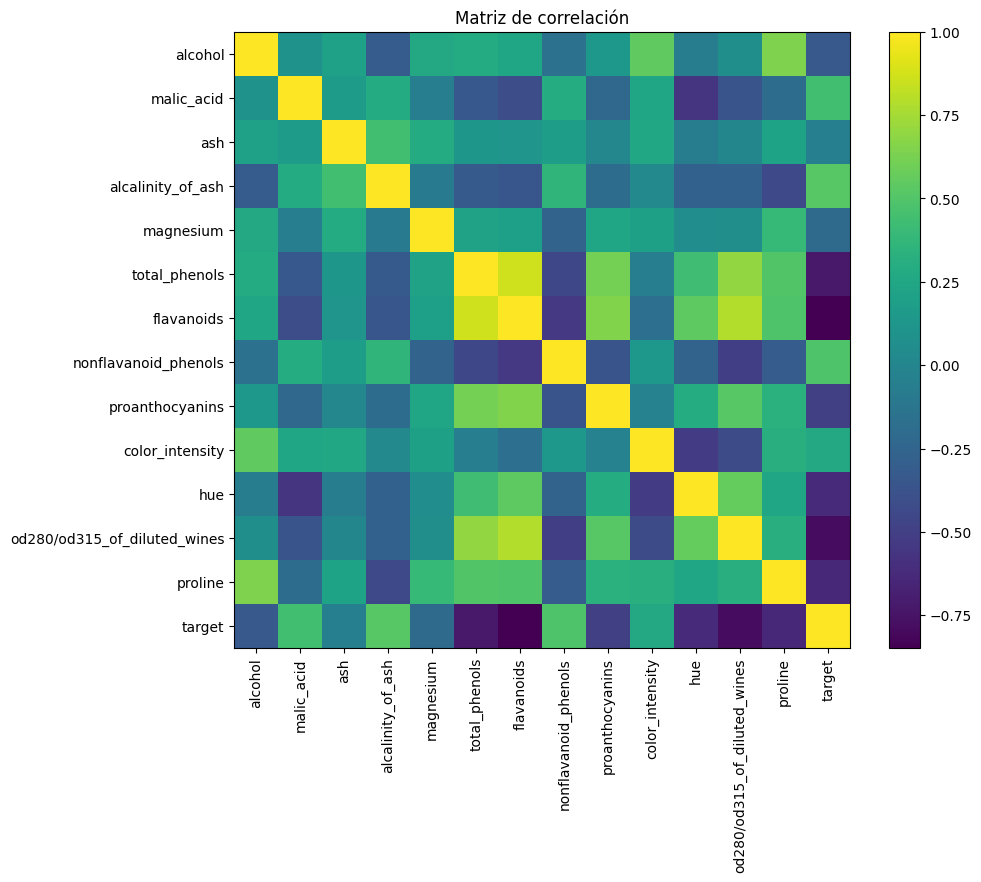

In [ ]:
corr = df.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Matriz de correlación")
plt.show()

In [ ]:
corr_target = df.corr()["target"].sort_values(ascending=False)

print(corr_target)

target                          1.000000
alcalinity_of_ash               0.517859
nonflavanoid_phenols            0.489109
malic_acid                      0.437776
color_intensity                 0.265668
ash                            -0.049643
magnesium                      -0.209179
alcohol                        -0.328222
proanthocyanins                -0.499130
hue                            -0.617369
proline                        -0.633717
total_phenols                  -0.719163
od280/od315_of_diluted_wines   -0.788230
flavanoids                     -0.847498
Name: target, dtype: float64


# Entrenamiento

## Split dataset Train y Test

In [ ]:
X = df.drop(columns="target")
y = df["target"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (142, 13)
Test: (36, 13)


## Escalado de datos

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
import os
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.ensemble import RandomForestClassifier

In [ ]:
BITACORA = "bitacora_experimentos.csv"

In [ ]:
def calcular_metricas(y_true, y_pred, sufijo):

    return {
        f"precision_{sufijo}": precision_score(
            y_true,
            y_pred,
            average="macro"
        ),

        f"recall_{sufijo}": recall_score(
            y_true,
            y_pred,
            average="macro"
        ),

        f"f1_{sufijo}": f1_score(
            y_true,
            y_pred,
            average="macro"
        ),

        f"accuracy_{sufijo}": accuracy_score(
            y_true,
            y_pred
        )
    }

In [ ]:
def registrar_experimento(
    experimento_id,
    modelo,
    hiperparametros,
    arquitectura,
    model
):

    fila = {

        "experimento_id": experimento_id,
        "modelo": modelo,
        "hiperparametros": str(hiperparametros),
        "arquitectura": arquitectura
    }

    # Train
    y_pred_train = model.predict(X_train)

    fila.update(
        calcular_metricas(
            y_train,
            y_pred_train,
            "train"
        )
    )

    # Test
    y_pred_test = model.predict(X_test)

    fila.update(
        calcular_metricas(
            y_test,
            y_pred_test,
            "test"
        )
    )

    pd.DataFrame([fila]).to_csv(
        BITACORA,
        mode="a",
        header=not os.path.exists(BITACORA),
        index=False
    )

    return fila

In [ ]:
configuraciones_rf = [

    {
        "n_estimators":100,
        "max_depth":5
    },

    {
        "n_estimators":200,
        "max_depth":10
    },

    {
        "n_estimators":300,
        "max_depth":None
    },

    {
        "n_estimators":150,
        "max_depth":8,
        "min_samples_leaf":2
    },

    {
        "n_estimators":400,
        "max_depth":15,
        "max_features":"sqrt"
    }

]

In [ ]:
resultados_rf = []
modelos_rf = []

for i, cfg in enumerate(configuraciones_rf, start=1):

    print("="*50)
    print(f"Entrenando RF_{i:02d}")
    print(cfg)

    modelo = RandomForestClassifier(
        **cfg,
        random_state=42
    )

    modelo.fit(
        X_train,
        y_train
    )

    modelos_rf.append(modelo)

    fila = registrar_experimento(
        experimento_id=f"RF_{i:02d}",
        modelo="random_forest",
        hiperparametros=cfg,
        arquitectura="Random Forest",
        model=modelo
    )

    resultados_rf.append(fila)

Entrenando RF_01
{'n_estimators': 100, 'max_depth': 5}
Entrenando RF_02
{'n_estimators': 200, 'max_depth': 10}
Entrenando RF_03
{'n_estimators': 300, 'max_depth': None}
Entrenando RF_04
{'n_estimators': 150, 'max_depth': 8, 'min_samples_leaf': 2}
Entrenando RF_05
{'n_estimators': 400, 'max_depth': 15, 'max_features': 'sqrt'}


In [ ]:
df_rf = pd.DataFrame(resultados_rf)

df_rf

,experimento_id,modelo,hiperparametros,arquitectura,precision_train,recall_train,f1_train,accuracy_train,precision_test,recall_test,f1_test,accuracy_test
0,RF_01,random_forest,"{'n_estimators': 100, 'max_depth': 5}",Random Forest,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,RF_02,random_forest,"{'n_estimators': 200, 'max_depth': 10}",Random Forest,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,RF_03,random_forest,"{'n_estimators': 300, 'max_depth': None}",Random Forest,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,RF_04,random_forest,"{'n_estimators': 150, 'max_depth': 8, 'min_sam...",Random Forest,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,RF_05,random_forest,"{'n_estimators': 400, 'max_depth': 15, 'max_fe...",Random Forest,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [ ]:
mejor_rf = df_rf.loc[df_rf["f1_test"].idxmax()]

display(mejor_rf)

,0
experimento_id,RF_01
modelo,random_forest
hiperparametros,"{'n_estimators': 100, 'max_depth': 5}"
arquitectura,Random Forest
precision_train,1.0
recall_train,1.0
f1_train,1.0
accuracy_train,1.0
precision_test,1.0
recall_test,1.0
